<br>

<div style="text-align: center">Confidential – Qualcomm Technologies, Inc. and/or its affiliated companies – May Contain Trade Secrets</div>

<div style="text-align: center; font-weight: bold">MAY CONTAIN U.S. AND INTERNATIONAL EXPORT CONTROLLED INFORMATION</div> <br>

**Takeaways:** Users will learn how to Quantize a model by run accuracy evaluator and analyzer tools on Qualcomm® Cloud AI (AIC) Inference Accelerator

**Before you start:** There are some commands (folder locations etc) that will need to be updated in this notebook based on your platform and installation location. Some commands might need sudo prefix to run properly.

**Last Verified Qualcomm Cloud AI Platform SDK and Apps SDK Version:** 1.9.1.25 

## Qualcomm Cloud AI Getting started with Distill-BERT

BERT (Bidirectional Encoder Representations from Transformers) is a neural network-based model that uses a transformer architecture. It is designed to understand the context and meaning of words in a sentence by capturing bidirectional dependencies.

DistilBERT is a small, fast and light Transformer model trained by distilling BERT base. It has 40% less parameters than bert-base-uncased, runs 60% faster while preserving over 95% of BERT's performances as measured on the GLUE language understanding benchmark.

In this example we will download the model and run accuracy tools to demonstrate model quantization and how to achieve target accuracy on the Cloud AI (AIC) accelerator card.

The following topics are covered in this notebook:

### Distill-BERT Example
   > 1) Setup and Download the model
   > 2) Update the Model
   > 3) Input data
   > 4) Evaluator
   > 5) Analyzer

### Setup and Download the Model
For setup, install the required Python packages mentioned under requirements.txt and then download the pretrained distilbert model.

In [1]:
!cat distillbert_setup.sh

pip install -r requirements.txt

if [ -d generatedModels ]
then
  rm -rf generatedModels
fi

optimum-cli export onnx --model distilbert-base-uncased-distilled-squad --cache_dir model_files/cased --opset 11 --task question-answering generatedModels/ONNX/uncased

In [2]:
!bash distillbert_setup.sh


[notice] A new release of pip is available: 23.0.1 -> 23.1.2
[notice] To update, run: pip install --upgrade pip
2023-06-29 01:57:15.767838: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/opt/qti-aic/dev/lib/x86_64
2023-06-29 01:57:15.767882: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-06-29 01:57:19.555708: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: :/opt/qti-aic/dev/lib/x86_64
2023-06-29 01:57:19.555750: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


Framework not specified. Using pt to export to ONNX.
Using framework PyTorch: 1.11.0+cu102
/opt/venv/lib/python3.8/site-packages/transformers/models/distilbert/modeling_distilbert.py:223: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  mask, torch.tensor(torch.finfo(scores.dtype).min)
Validating ONNX model generatedModels/ONNX/uncased/model.onnx...
	-[✓] ONNX model output names match reference model (start_logits, end_logits)
	- Validating ONNX Model output "start_logits":
		-[✓] (2, 16) matches (2, 16)
		-[✓] all values close (atol: 0.0001)
	- Validating ONNX Model output "end_logits":
		-[✓] (2, 16) matches (2, 16)
		-[✓] all values close (atol: 0.0001)
The ONNX export succeeded and the exported model was saved at: generatedModels/

Here's the BERT base ONNX model.

In [3]:
!ls ./generatedModels/ONNX/uncased

config.json  special_tokens_map.json  tokenizer_config.json
model.onnx   tokenizer.json	      vocab.txt


Here's the BERT configuration we'll be working with.

In [4]:
!cat ./generatedModels/ONNX/uncased/config.json

{
  "_name_or_path": "distilbert-base-uncased-distilled-squad",
  "activation": "gelu",
  "architectures": [
    "DistilBertForQuestionAnswering"
  ],
  "attention_dropout": 0.1,
  "dim": 768,
  "dropout": 0.1,
  "hidden_dim": 3072,
  "initializer_range": 0.02,
  "max_position_embeddings": 512,
  "model_type": "distilbert",
  "n_heads": 12,
  "n_layers": 6,
  "pad_token_id": 0,
  "qa_dropout": 0.1,
  "seq_classif_dropout": 0.2,
  "sinusoidal_pos_embds": false,
  "tie_weights_": true,
  "transformers_version": "4.30.2",
  "vocab_size": 30522
}


### Update Model

* Modify the onnx file to handle constants > FP16_Max and < FP16_Min
* Update model dimensions.

#### Modify the onnx file to handle constants

Find constants which are out of FP16 range and clip to FP16 range.

In [5]:
import onnx
from onnx import numpy_helper
import numpy as np

model_card = 'distilbert'
gen_models_path = f"generatedModels/ONNX/uncased"
model_base_name = model_card

def fix_onnx_fp16(
    gen_models_path: str,
    model_base_name: str,
) -> str:
    finfo = np.finfo(np.float16)
    fp16_max = finfo.max
    fp16_min = finfo.min

    model = onnx.load(f"generatedModels/ONNX/uncased/model.onnx")
    fp16_fix = False
    for tensor in onnx.external_data_helper._get_all_tensors(model):
        nptensor = numpy_helper.to_array(tensor, gen_models_path)
        if nptensor.dtype == np.float32 and (
            np.any(nptensor > fp16_max) or np.any(nptensor < fp16_min)
        ):
            # print(f'tensor value : {nptensor} above {fp16_max} or below {fp16_min}')
            nptensor = np.clip(nptensor, fp16_min, fp16_max)
            new_tensor = numpy_helper.from_array(nptensor, tensor.name)
            tensor.CopyFrom(new_tensor)
            fp16_fix = True
            
    if fp16_fix:
        # Save FP16 model
        print("Found constants out of FP16 range, clipped to FP16 range")
        model_base_name += "_fix_outofrange_fp16"
        onnx.save(model, f=f"{gen_models_path}/{model_base_name}.onnx")
        print(f"Saving modified onnx file at {gen_models_path}/{model_base_name}.onnx")
    return model_base_name

fp16_model_name = fix_onnx_fp16(gen_models_path=gen_models_path, model_base_name=model_base_name)

Found constants out of FP16 range, clipped to FP16 range
Saving modified onnx file at generatedModels/ONNX/uncased/distilbert_fix_outofrange_fp16.onnx


In [6]:
!ls ./generatedModels/ONNX/uncased

config.json			     special_tokens_map.json  vocab.txt
distilbert_fix_outofrange_fp16.onnx  tokenizer.json
model.onnx			     tokenizer_config.json


#### Update model dimensions.

In [7]:
!python3 generateModel.py --model-ip-path ./generatedModels/ONNX/uncased/distilbert_fix_outofrange_fp16.onnx --model-op-path ./generatedModels/ONNX/uncased/prepmodel.onnx

In [8]:
!ls ./generatedModels/ONNX/uncased

config.json			     special_tokens_map.json
distilbert_fix_outofrange_fp16.onnx  tokenizer.json
model.onnx			     tokenizer_config.json
prepmodel.onnx			     vocab.txt


### Input data
Download the squadv1.1 dataset.

In [9]:
!rm -rf squadv1

In [10]:
import glob
import os
import sys

dataset_base_path = 'squadv1'
download=True
if download:
    if not os.path.exists(dataset_base_path):
        os.mkdir('squadv1')
        print("Fetching squadv1.1 dataset")
        !cd 'squadv1' && git clone https://github.com/rajpurkar/SQuAD-explorer && cd ..
        print("Dataset download complete")
        print("Creating input and calibration list files")
        !{sys.executable} setup_squadv1.py
        print("Creating input and calibration list files complete")
    else:
        print("squadv1 dataset folder already exists")

Fetching squadv1.1 dataset
Cloning into 'SQuAD-explorer'...
remote: Enumerating objects: 5545, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 5545 (delta 0), reused 6 (delta 0), pack-reused 5539
Receiving objects: 100% (5545/5545), 52.22 MiB | 36.20 MiB/s, done.
Resolving deltas: 100% (3552/3552), done.
Dataset download complete
Creating input and calibration list files
please update the dataset path to: squadv1/SQuAD-explorer/dataset/
Creating input and calibration list files complete


Generate .raw input files at location "input_raw_data/preproc/"

In [11]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py \
    -config distillbert_eval.yaml \
    -silent \
    -cleanup intermediate \
    -set-global count:1 \
    -pipeline-end preproc \
    -work-dir input_raw_data

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/venv/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
add example index and unique id: 100%|████| 327/327 [00:00<00:00, 352127.70it/s]
INFO: Executing Preprocessors for calibration inputs
INFO: Calibration Preprocessing Took 0.4229555130004883 seconds.
INFO: Executing Preprocessors
INFO: Input Preprocessing Took 0.003818511962890625 seconds.
INFO: qacc pipeline ended successfully


Generate input list file.

In [12]:
%%writefile inputlist.txt
input_raw_data/preproc/batched-inp-0-0.raw,input_raw_data/preproc/batched-inp-0-1.raw

Overwriting inputlist.txt


### Evaluator

* We use qaic-acc-evaluator.py to evaluate the model using different precisions.
* We need a config which consists of the plugin information for dataloading, preprocess, postprocess and metric calculation.
* Config also has the information regarding the different available quantization options and their combinations.
* Run the below cell for the available options of the evaluator.


In [13]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py -h

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
usage: qaic-acc-evaluator.py [-h] -config CONFIG
                             [-pipeline-start {preproc,compiled,infer}]
                             [-pipeline-end {preproc,compiled,infer,postproc,metric}]
                             [-preproc-file PREPROC_FILE]
                             [-infer-file INFER_FILE] [-calib-file CALIB_FILE]
                             [-disable-memory-pipeline]
                             [-cleanup {end,intermediate}]
                             [-platform PLATFORM] [-platform-tag PLATFORM_TAG]
                             [-silent] [-batchsize BATCHSIZE]
                             [-device-id DEVICE_ID] [-work-dir WORK_DIR]
                             [-platform-tag-params PLATFORM_TAG_PARAMS [PLATFORM_TAG_PARAMS ...]]
                             [-onnx-symbol ONNX_SYMBOL [ONNX_SYMBOL ...

* We need a config which consists of the plugin information for dataloading, preprocess, postprocess and evaluation metric.
* Config also has the information regarding the different available quantization options and their combinations.
* We can also set number of input samples through the config or command line.
* The following cell has the contents of the config file.

In [14]:
!cat distillbert_eval.yaml

model:
    info:
        desc: "DistilBERT with SL=128"
        batchsize: 1
    globals:
        sl: 128
        npi_file: model_configs/public/bert/npi_distilbert_known_ops.yaml
        calib_val: 99.9992
        count: -1
        calib: -1
        squad_ver: 1
        model_name: distilbert-base-uncased-distilled-squad 
        cached_path: /home/ml-datasets/huggingface/cache/distilbert-base-uncased
        onnx_path: generatedModels/ONNX/uncased/prepmodel.onnx

    dataset:
        name: SQUAD
        path: '/local/mnt/workspace/stangade/qaic-notebooks/quick-start-bert-base/distilbert/squadv1/SQuAD-explorer/dataset/'
        inputlist_file: datafile.txt
        annotation_file: dev-v1.1.json
        calibration:
            type: dataset
            file: calib_datafile.txt
        transformations:
            - plugin:
                  name: create_squad_examples
                  params:
                      squad_version: $squad_ver
                      vocabulary: $model_nam

Run evaluator with fp16 precision.

In [15]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py \
    -config distillbert_eval.yaml \
    -silent \
    -cleanup intermediate \
    -platform-tag aic_fp16 \
    -set-global count:-1 \
    -set-global onnx_path:generatedModels/ONNX/uncased/prepmodel.onnx \
    -work-dir aic_fp16

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/venv/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:04<00:00, 11.49it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:14<00:00, 737.91it/s
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 196465.40it/s
add example index and unique id: 100%|████| 327/327 [00:00<00:00, 541681.44it/s]
INFO: Disabling comparator as -cleanup intermediate is selected
INFO: Total platform configurations: 1
INFO: Total inputs for execution: 18498 and calibration: 0
INFO: Approximate disk usage  - 54.19 MB
INFO: Cleaning up model..
INF

Run pgq_sweep

In [18]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py \
    -config distillbert_eval.yaml \
    -silent \
    -cleanup intermediate \
    -platform-tag aic_int8 \
    -set-global count:-1 \
    -set-global onnx_path:generatedModels/ONNX/uncased/prepmodel.onnx \
    -work-dir aic_int8

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/venv/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:04<00:00, 11.19it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:14<00:00, 727.91it/s
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 195396.02it/s
add example index and unique id: 100%|████| 327/327 [00:00<00:00, 405061.25it/s]
INFO: Disabling comparator as -cleanup intermediate is selected
INFO: Total platform configurations: 12
INFO: Total inputs for execution: 18498 and calibration: 587
INFO: Approximate disk usage  - 254.05 MB
INFO: Cleaning up model..

### Analyzer
Analyzer helps us to find the sensitivity of each node which in turn helps us to select the nodes that go into the npi file to obatin the accuracy.

Run the below command to see all the available options for Analyzer run.

In [19]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py -h

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
INFO: Caffe engine is unsupported in this environment.
usage: qaic-acc-analyzer.py [-h] -model MODEL -input-list INPUT_LIST
                            [-reference {interpreter,onnxrt,tensorflow,caffe,none}]
                            [-input-info INPUT_INFO [INPUT_INFO ...]]
                            [-snooping {layerwise,oneshot,fp16sweep,amp}]
                            [-start-from-layer-output START_FROM_LAYER_OUTPUT]
                            [-end-layer-output END_LAYER_OUTPUT]
                            [-skip-layers SKIP_LAYERS]
                            [-skip-layer-outputs SKIP_LAYER_OUTPUTS]
                            [-add-layers ADD_LAYERS]
                            [-add-layer-outputs ADD_LAYER_OUTPUTS]
                            [-top-partition]
                            [-skip-layer-patterns SKIP_LA

   
Run Accuracy analyzer
* We use layer-wise option and run the analyzer command.
* This run may take long time depending on how long the compilation of the model takes (i.e., how big the model is).
* Once this run is complete, we shall get a CSV file (layerwise.csv) containing the accuracy information about all the nodes.

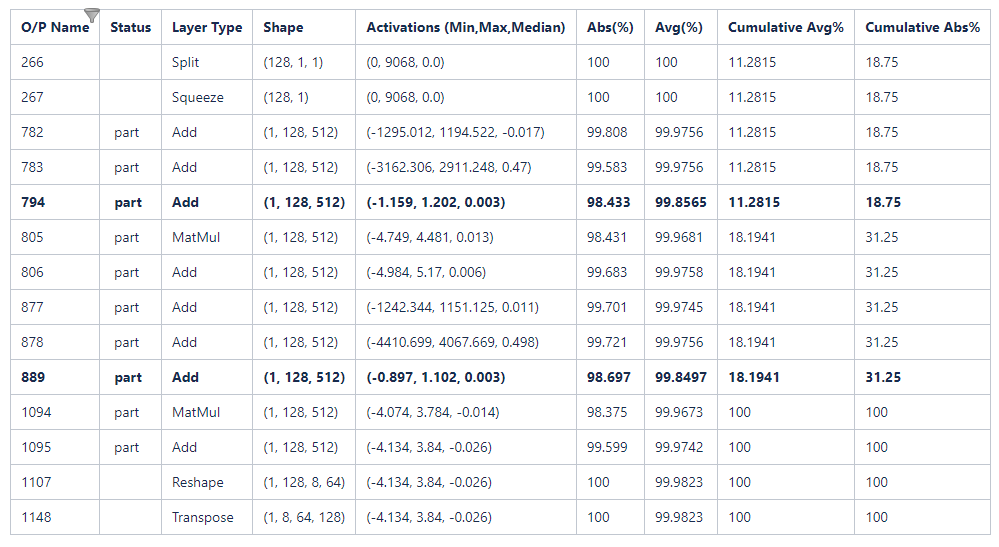



In [20]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-analyzer.py \
    -model=generatedModels/ONNX/uncased/prepmodel.onnx \
    -input-list=inputlist.txt \
    -snooping=layerwise \
    -precision=int8 \
    -reference=onnxrt \
    -enable-minimodel \
    -aic-compile-args "quantization-schema-activations=asymmetric;quantization-schema-constants=symmetric;quantization-calibration=KLMinimizationV2;enable-rowwise=True" \
    -silent \
    -comparator abs,rme,avg,l1norm,l2norm \
    -onnx-symbol seq_len:128 \
    -onnx-symbol batch_size:1 \
    -work-dir analyzer_run

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
INFO: Caffe engine is unsupported in this environment.
INFO: QAIC Model Analyzer
INFO: Cleaned and Optimized model is saved at analyzer_run/cleanmodel.onnx
INFO: Total no of nodes in the cleaned graph : 334
INFO: Node types and count in the cleaned graph:
   op_type  count
       Add     82
    MatMul     49
   Reshape     30
ReduceMean     26
       Div     25
       Mul     25
 Transpose     24
       Sub     13
       Pow     13
      Sqrt     13
     Equal      6
    Expand      6
     Where      6
   Softmax      6
       Erf      6
   Squeeze      2
    Gather      1
     Split      1
INFO: Snooping all intermediate outputs of model
INFO: Captured reference onnxrt session data
INFO: Captured onnx profile
INFO: Compiling and executing original model...
loading /opt/qti-aic/dev/lib/x86_64/libQAic.so
              Layer Type   

Run Evaluator with mixed precision to see if it gets to the target accuarcy.

In [21]:
!python3 /opt/qti-aic/tools/qaic-pytools/qaic-acc-evaluator.py \
    -config distillbert_eval.yaml \
    -silent -cleanup intermediate \
    -platform-tag compare_fp32_int8_mixed_precision \
    -set-global count:-1 \
    -set-global onnx_path:generatedModels/ONNX/uncased/prepmodel.onnx \
    -work-dir mixed_precision

/opt/venv/lib/python3.8/site-packages/paramiko/transport.py:236: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,
/opt/venv/lib/python3.8/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
INFO: Loading model config
INFO: Running Accuracy Evaluator using Memory Pipeline
INFO: Executing dataset plugins
100%|███████████████████████████████████████████| 48/48 [00:04<00:00, 11.27it/s]
convert squad examples to features: 100%|█| 10570/10570 [00:14<00:00, 736.12it/s
add example index and unique id: 100%|█| 10570/10570 [00:00<00:00, 214717.49it/s
add example index and unique id: 100%|████| 327/327 [00:00<00:00, 369587.01it/s]
INFO: Disabling comparator as -cleanup intermediate is selected
INFO: Total platform configurations: 2
INFO: Total inputs for execution: 18498 and calibration: 587
INFO: Approximate disk usage  - 73.4 MB
INFO: Cleaning up model..
IN

<br>
<div style="text-align: center">Confidential – Qualcomm Technologies, Inc. and/or its affiliated companies – May Contain Trade Secrets</div>

<div style="text-align: center; font-weight: bold">MAY CONTAIN U.S. AND INTERNATIONAL EXPORT CONTROLLED INFORMATION</div>